<a href="https://colab.research.google.com/github/matiasCaileo/preprocesamiento-de-datos/blob/main/semana2_analisis_titanic_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Estadístico - Dataset Titanic
Dataset clásico de Kaggle con información de pasajeros del Titanic.


## 1. Cargar librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset (mismo que Kaggle, no necesita descarga)
df = sns.load_dataset('titanic')
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()


Filas: 891, Columnas: 15


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Estadísticas descriptivas

In [2]:
# Resumen estadístico de las variables numéricas
df.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
# Valores nulos por columna
df.isnull().sum()


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


## 3. Gráficos de distribución

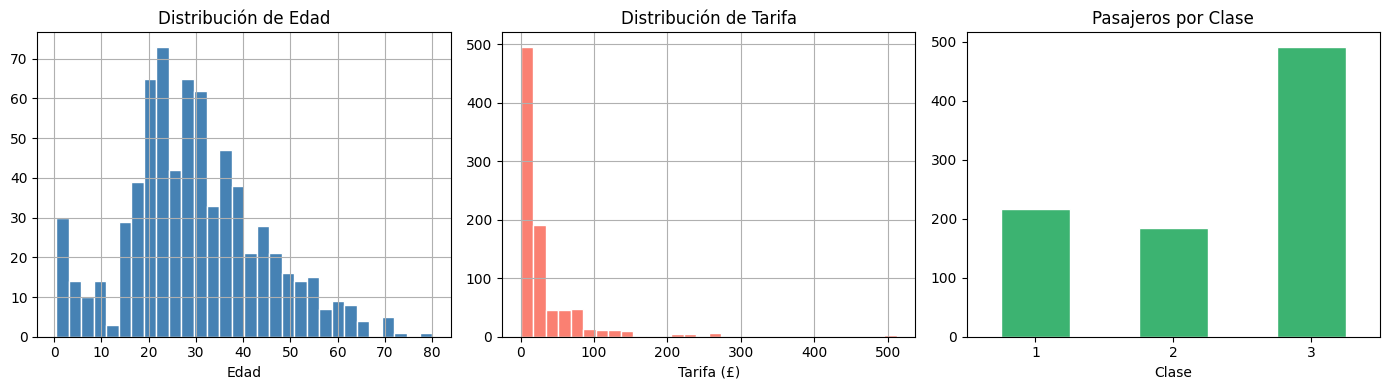

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df['age'].dropna().hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Edad')
axes[0].set_xlabel('Edad')

df['fare'].dropna().hist(bins=30, ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Distribución de Tarifa')
axes[1].set_xlabel('Tarifa (£)')

df['pclass'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Pasajeros por Clase')
axes[2].set_xlabel('Clase')
axes[2].tick_params(rotation=0)

plt.tight_layout()
plt.show()


## 4. Detección de Outliers (método IQR)

In [5]:
def detectar_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    outliers = col[(col < Q1 - 1.5*IQR) | (col > Q3 + 1.5*IQR)]
    return len(outliers)

for var in ['age', 'fare', 'sibsp', 'parch']:
    n = detectar_outliers(df[var].dropna())
    print(f"{var}: {n} outliers")


age: 11 outliers
fare: 116 outliers
sibsp: 46 outliers
parch: 213 outliers


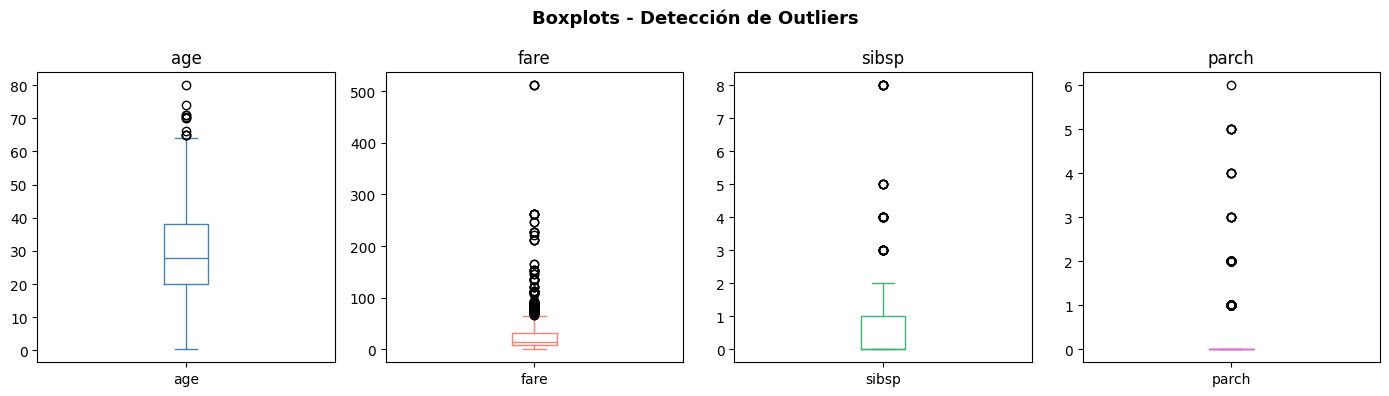

In [6]:
# Boxplots para visualizar outliers
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, var, color in zip(axes, ['age', 'fare', 'sibsp', 'parch'],
                           ['steelblue', 'salmon', 'mediumseagreen', 'orchid']):
    df[var].dropna().plot(kind='box', ax=ax, color=color)
    ax.set_title(var)

plt.suptitle('Boxplots - Detección de Outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Supervivencia por sexo y clase

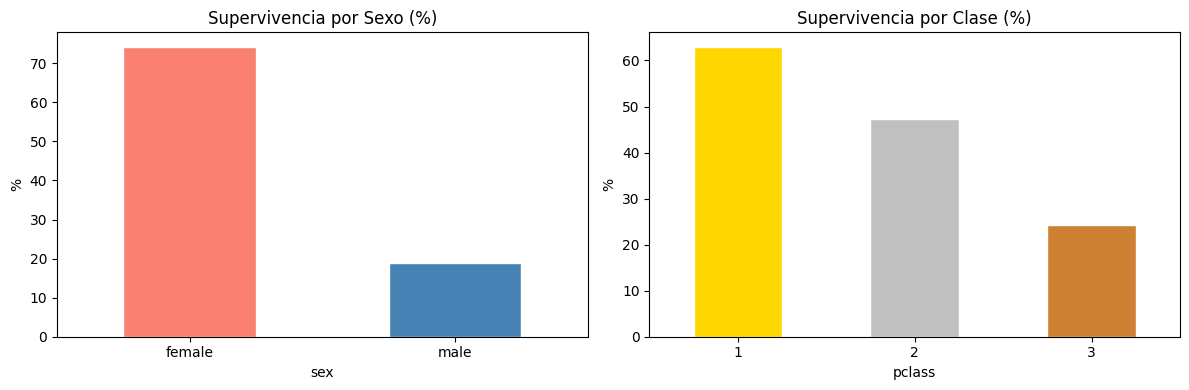

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Por sexo
df.groupby('sex')['survived'].mean().mul(100).plot(kind='bar', ax=axes[0],
    color=['salmon', 'steelblue'], edgecolor='white')
axes[0].set_title('Supervivencia por Sexo (%)')
axes[0].set_ylabel('%')
axes[0].tick_params(rotation=0)

# Por clase
df.groupby('pclass')['survived'].mean().mul(100).plot(kind='bar', ax=axes[1],
    color=['gold', 'silver', '#cd7f32'], edgecolor='white')
axes[1].set_title('Supervivencia por Clase (%)')
axes[1].set_ylabel('%')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.show()


## 6. Conclusiones

- **Edad promedio:** 30 años, con bastante variación entre pasajeros.
- **Tarifa (fare):** Muy sesgada — la mayoría pagó poco, pero hay outliers con tarifas muy altas (de primera clase clase).
- **Outliers:** La variable `fare` es la que más outliers tiene; son válidos, no errores.
- **Supervivencia:** Las mujeres sobrevivieron mucho más que los hombres (74% vs 19%).
- **Clase:** Los pasajeros de 1ª clase tuvieron mayor probabilidad de sobrevivir que los de tercera clase.
